### Deep Q-Network (DQN): T-Rex Game

Prepared by: [Tirtharaj Dash](https://tirtharajdash.github.io); with the help from: [claude](claude.ai)

Demonstrates DQN on a custom Chrome T-Rex game built from scratch.

**State** (5 features): dino height, dino vertical velocity, distance to next cactus, cactus height, game speed (all normalised).

**Actions**: 0 = do nothing, 1 = jump

**Reward**: +1 per step survived, -1 on collision

In [1]:
#!pip install pygame #numpy matplotlib

In [2]:
import numpy as np
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.13.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print("seeded.")

cuda
seeded.


#### T-Rex Environment

In [4]:
class TRexEnv:
    """
    Minimal T-Rex game.
    y=0 is top of screen; y=GROUND_Y is the ground line.
    self.dino_y stores the bottom edge of the dino rectangle.
    """

    WIDTH, HEIGHT = 600, 160
    GROUND_Y      = 130

    DINO_X = 60
    DINO_W = 20
    DINO_H = 15

    JUMP_VEL   = -13.0
    GRAVITY    =   0.75

    CACTUS_W     = 14
    CACTUS_MIN_H = 28
    CACTUS_MAX_H = 52

    INIT_SPEED  =  5.0
    SPEED_DELTA =  0.003
    MAX_SPEED   = 14.0

    MIN_GAP = 200
    MAX_GAP = 360

    def __init__(self, render=False, fps=60):
        self.render_mode = render
        self.fps         = fps
        self.screen      = None
        if render:
            pygame.init()
            self.screen = pygame.display.set_mode((self.WIDTH, self.HEIGHT))
            pygame.display.set_caption('T-Rex DQN')
            self.clock = pygame.time.Clock()
            self.font  = pygame.font.SysFont('monospace', 18)

    def reset(self):
        self.dino_y     = float(self.GROUND_Y)
        self.dino_vy    = 0.0
        self.on_ground  = True
        self.speed      = self.INIT_SPEED
        self.t          = 0
        self.cacti      = []
        self.next_spawn = self.WIDTH + random.randint(80, 180)
        return self._state()

    def _state(self):
        ahead = [c for c in self.cacti if c['x'] + self.CACTUS_W > self.DINO_X]
        if ahead:
            nc   = min(ahead, key=lambda c: c['x'])
            dist = (nc['x'] - self.DINO_X) / self.WIDTH
            ch   = nc['h'] / self.CACTUS_MAX_H
        else:
            dist, ch = 1.0, 0.5
        dy  = (self.GROUND_Y - self.dino_y) / self.GROUND_Y
        dvy = self.dino_vy / abs(self.JUMP_VEL)
        spd = (self.speed - self.INIT_SPEED) / (self.MAX_SPEED - self.INIT_SPEED)
        return np.array([dy, dvy, dist, ch, spd], dtype=np.float32)

    def step(self, action):
        if action == 1 and self.on_ground:
            self.dino_vy   = self.JUMP_VEL
            self.on_ground = False

        self.dino_vy += self.GRAVITY
        self.dino_y   = min(self.dino_y + self.dino_vy, float(self.GROUND_Y))
        if self.dino_y >= self.GROUND_Y:
            self.dino_vy   = 0.0
            self.on_ground = True

        self.speed = min(self.speed + self.SPEED_DELTA, self.MAX_SPEED)
        self.t    += 1

        for c in self.cacti:
            c['x'] -= self.speed
        self.cacti = [c for c in self.cacti if c['x'] + self.CACTUS_W > 0]

        self.next_spawn -= self.speed
        if self.next_spawn <= self.WIDTH:
            h = random.randint(self.CACTUS_MIN_H, self.CACTUS_MAX_H)
            self.cacti.append({'x': float(self.WIDTH), 'h': h})
            self.next_spawn = self.WIDTH + random.randint(self.MIN_GAP, self.MAX_GAP)

        done   = self._collides()
        reward = 1.0 if not done else -1.0

        if self.render_mode and self.screen:
            self._draw()

        return self._state(), reward, done

    def _collides(self):
        m  = 3
        dl = self.DINO_X + m
        dr = self.DINO_X + self.DINO_W - m
        dt = self.dino_y - self.DINO_H + m
        db = self.dino_y - m
        for c in self.cacti:
            cl = c['x'] + m
            cr = c['x'] + self.CACTUS_W - m
            ct = self.GROUND_Y - c['h']
            if dr > cl and dl < cr and db > ct and dt < self.GROUND_Y:
                return True
        return False

    def _draw(self):
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.close()
                return
        self.screen.fill((255, 255, 255))
        pygame.draw.line(self.screen, (120, 120, 120),
                         (0, self.GROUND_Y), (self.WIDTH, self.GROUND_Y), 2)
        pygame.draw.rect(self.screen, (50, 80, 200),
                         (self.DINO_X, int(self.dino_y) - self.DINO_H,
                          self.DINO_W, self.DINO_H))
        for c in self.cacti:
            pygame.draw.rect(self.screen, (34, 120, 34),
                             (int(c['x']), self.GROUND_Y - c['h'],
                              self.CACTUS_W, c['h']))
        txt = self.font.render(
            f"t={self.t}  speed={self.speed:.1f}", True, (80, 80, 80))
        self.screen.blit(txt, (10, 8))
        pygame.display.flip()
        self.clock.tick(self.fps)

    def close(self):
        if self.screen:
            pygame.quit()
            self.screen = None

    def get_frame(self):
        surf = pygame.Surface((self.WIDTH, self.HEIGHT))
        surf.fill((255, 255, 255))
        pygame.draw.line(surf, (120, 120, 120),
                         (0, self.GROUND_Y), (self.WIDTH, self.GROUND_Y), 2)
        surf.fill((50, 80, 200),
                  (self.DINO_X, int(self.dino_y) - self.DINO_H,
                   self.DINO_W, self.DINO_H))
        for c in self.cacti:
            surf.fill((34, 120, 34),
                      (int(c['x']), self.GROUND_Y - c['h'],
                       self.CACTUS_W, c['h']))
        return pygame.surfarray.array3d(surf).transpose(1, 0, 2)

In [5]:
# run a random episode
env   = TRexEnv(render=False)
state = env.reset()
print('State dim :', state.shape)
print('Initial   :', np.round(state, 3))
for _ in range(5):
    s, r, done = env.step(random.randint(0, 1))
    print(f'  state={np.round(s,3)}  r={r}  done={done}')
    if done:
        break

State dim : (5,)
Initial   : [0.  0.  1.  0.5 0. ]
  state=[0.  0.  1.  0.5 0. ]  r=1.0  done=False
  state=[0.    0.    1.    0.5   0.001]  r=1.0  done=False
  state=[ 0.094 -0.942  1.     0.5    0.001]  r=1.0  done=False
  state=[ 0.183 -0.885  1.     0.5    0.001]  r=1.0  done=False
  state=[ 0.265 -0.827  1.     0.5    0.002]  r=1.0  done=False


#### Our Q-Network

In [6]:
class QNetwork(nn.Module):
    """
    FC network: state (5,) -> Q-values for each action (2,).
    """

    def __init__(self, state_dim=5, action_dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)


net = QNetwork()
print(net)
dummy = torch.zeros(1, 5)
print('Output:', net(dummy))  # [Q(s,do_nothing), Q(s,jump)]

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Output: tensor([[-0.0239,  0.0148]], grad_fn=<AddmmBackward0>)


#### Replay Buffer

In [7]:
class ReplayBuffer:
    """Circular buffer storing (s, a, r, s', done) transitions."""

    def __init__(self, capacity=20000):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, float(done)))

    def sample(self, n):
        batch        = random.sample(self.buf, n)
        s, a, r, s2, d = zip(*batch)
        return (
            np.stack(s).astype(np.float32),
            np.array(a, dtype=np.int64),
            np.array(r, dtype=np.float32),
            np.stack(s2).astype(np.float32),
            np.array(d, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buf)

#### DQN Agent

Maintains two networks:
- **online** $Q_\theta$: updated every step
- **target** $Q_{\theta^-}$: frozen, synced every `target_update_freq` steps

Loss: $\mathcal{L}(\theta) = \left(Q_\theta(s,a) - [r + \gamma \max_{a'} Q_{\theta^-}(s',a')]\right)^2$

In [8]:
class DQNAgent:

    def __init__(
        self,
        state_dim=5, action_dim=2,
        lr=1e-4, gamma=0.99,
        eps_start=1.0, eps_end=0.02, eps_decay=0.9995,
        batch_size=64, target_update_freq=200,
        buffer_capacity=50000
    ):
        self.action_dim         = action_dim
        self.gamma              = gamma
        self.eps                = eps_start
        self.eps_end            = eps_end
        self.eps_decay          = eps_decay
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.update_count       = 0

        self.online     = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.online.state_dict())
        self.target_net.eval()
            
        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_capacity)

    def act(self, state):
        if random.random() < self.eps:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            return self.online(
                torch.FloatTensor(state).unsqueeze(0).to(device)
            ).argmax().item()

    def push(self, s, a, r, s2, done):
        self.buffer.push(s, a, r, s2, done)

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None

        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        s  = torch.FloatTensor(s).to(device)
        a  = torch.LongTensor(a).unsqueeze(1).to(device)
        r  = torch.FloatTensor(r).unsqueeze(1).to(device)
        s2 = torch.FloatTensor(s2).to(device)
        d  = torch.FloatTensor(d).unsqueeze(1).to(device)

        q_pred = self.online(s).gather(1, a)

        with torch.no_grad():
            q_next   = self.target_net(s2).max(1, keepdim=True)[0]
            q_target = r + self.gamma * q_next * (1.0 - d)

        loss = nn.SmoothL1Loss()(q_pred, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 1.0)
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.online.state_dict())

        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        return loss.item()

#### Training

Runs without pygame for speed. Prints stats every 50 episodes.

In [9]:
def train(num_episodes=2000, max_steps=3000, print_every=50):
    agent  = DQNAgent()
    scores = []
    losses = []

    for ep in range(num_episodes):
        env   = TRexEnv(render=False)
        state = env.reset()
        ep_losses = []

        for _ in range(max_steps):
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.push(state, action, reward, next_state, done)
            l = agent.update()
            if l is not None:
                ep_losses.append(l)
            state = next_state
            if done:
                break

        scores.append(env.t)
        losses.append(np.mean(ep_losses) if ep_losses else 0.0)

        if (ep + 1) % print_every == 0:
            avg = np.mean(scores[-50:])
            print(f'ep {ep+1:4d}  score {env.t:5d}  '
                  f'avg50={avg:6.1f}  '
                  f'eps={agent.eps:.3f}  '
                  f'loss={np.mean(losses[-50:]):.4f}')

    return agent, scores, losses

In [10]:
if not os.path.exists("trex_dqn.pth"):
    agent, scores, losses = train(num_episodes=1500)
    torch.save(agent.online.state_dict(), "trex_dqn.pth")
    print("Saved: trex_dqn.pth")
else:
    print("Model found, skipping training.")

ep   50  score   336  avg50= 273.8  eps=0.020  loss=0.1177
ep  100  score   134  avg50= 253.3  eps=0.020  loss=0.2389
ep  150  score   167  avg50= 213.3  eps=0.020  loss=0.3137
ep  200  score   170  avg50= 234.7  eps=0.020  loss=0.3540
ep  250  score   169  avg50= 236.4  eps=0.020  loss=0.3995
ep  300  score   133  avg50= 208.8  eps=0.020  loss=0.4166
ep  350  score   315  avg50= 211.5  eps=0.020  loss=0.4345
ep  400  score   132  avg50= 220.7  eps=0.020  loss=0.4485
ep  450  score   136  avg50= 221.3  eps=0.020  loss=0.4502
ep  500  score   132  avg50= 227.9  eps=0.020  loss=0.4531
ep  550  score   181  avg50= 251.8  eps=0.020  loss=0.4273
ep  600  score   249  avg50= 229.5  eps=0.020  loss=0.4206
ep  650  score   177  avg50= 258.5  eps=0.020  loss=0.4245
ep  700  score   125  avg50= 232.6  eps=0.020  loss=0.4137
ep  750  score  1433  avg50= 277.5  eps=0.020  loss=0.4245
ep  800  score   169  avg50= 282.4  eps=0.020  loss=0.3899
ep  850  score   177  avg50= 260.9  eps=0.020  loss=0.38

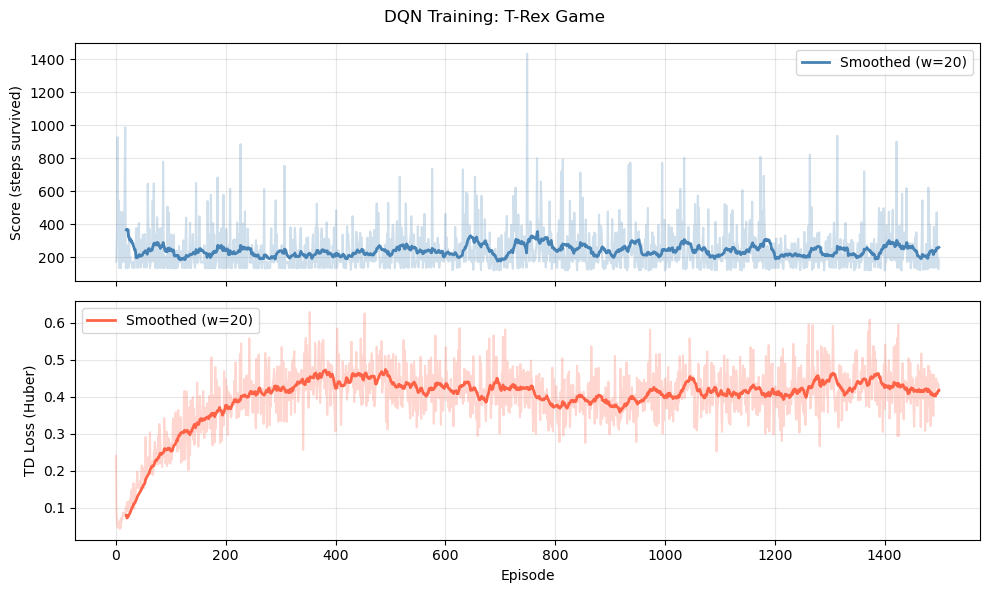

In [11]:
# How does training look?
def smooth(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(scores, alpha=0.25, color='steelblue')
ax1.plot(range(19, len(scores)), smooth(scores),
         color='steelblue', lw=2, label='Smoothed (w=20)')
ax1.set_ylabel('Score (steps survived)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(losses, alpha=0.25, color='tomato')
ax2.plot(range(19, len(losses)), smooth(losses),
         color='tomato', lw=2, label='Smoothed (w=20)')
ax2.set_ylabel('TD Loss (Huber)')
ax2.set_xlabel('Episode')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('DQN Training: T-Rex Game')
plt.tight_layout()
plt.savefig('trex_training.png', dpi=150)
plt.show()

#### Let's load the trained model to play

Score: 119 steps


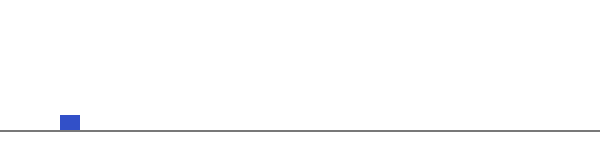

In [14]:
import imageio
from IPython.display import Image, display

pygame.init()

model = QNetwork(state_dim=5, action_dim=2).to(device)
model.load_state_dict(torch.load("trex_dqn.pth", map_location=device))
model.eval()

env    = TRexEnv(render=False)
state  = env.reset()
frames = []

while True:
    with torch.no_grad():
        action = model(
            torch.FloatTensor(state).unsqueeze(0).to(device)
        ).argmax().item()
    state, _, done = env.step(action)
    frames.append(env.get_frame())
    if done:
        break

pygame.quit()

imageio.mimsave("trex_demo.gif", frames, fps=30)
print(f"Score: {env.t} steps")
display(Image("trex_demo.gif"))

In [13]:
random.seed(SEED)
np.random.seed(SEED)

N = 100
ep_scores = []

for ep in range(N):
    env   = TRexEnv(render=False)
    state = env.reset()
    while True:
        with torch.no_grad():
            action = model(
                torch.FloatTensor(state).unsqueeze(0).to(device)
            ).argmax().item()
        state, _, done = env.step(action)
        if done:
            break
    ep_scores.append(env.t)
    print(f"Episode {ep}: score {env.t}")

print(f"Mean score over {N} episodes: {np.mean(ep_scores):.1f} +/- {np.std(ep_scores):.1f}")

Episode 0: score 133
Episode 1: score 121
Episode 2: score 120
Episode 3: score 123
Episode 4: score 122
Episode 5: score 129
Episode 6: score 126
Episode 7: score 127
Episode 8: score 124
Episode 9: score 127
Episode 10: score 133
Episode 11: score 119
Episode 12: score 120
Episode 13: score 121
Episode 14: score 135
Episode 15: score 121
Episode 16: score 123
Episode 17: score 125
Episode 18: score 123
Episode 19: score 121
Episode 20: score 131
Episode 21: score 127
Episode 22: score 130
Episode 23: score 135
Episode 24: score 127
Episode 25: score 131
Episode 26: score 136
Episode 27: score 128
Episode 28: score 130
Episode 29: score 133
Episode 30: score 127
Episode 31: score 118
Episode 32: score 125
Episode 33: score 120
Episode 34: score 137
Episode 35: score 131
Episode 36: score 128
Episode 37: score 135
Episode 38: score 128
Episode 39: score 123
Episode 40: score 131
Episode 41: score 120
Episode 42: score 120
Episode 43: score 123
Episode 44: score 132
Episode 45: score 12